# diagrammar

> A library to show grammars graphically

[nbdev](https://nbdev.fast.ai/getting_started.html)

In [ ]:
#| default_exp diagrammar

In [ ]:
#| hide
from nbdev.showdoc import *

A **graph** is a set of nodes and a set of edges between them. In order to *interconnect* those graphs between them, we will distinguish in each graph. a set of **ingoing** nodes an a set of **outgoing** nondes.

We define operations between **graphs** g,h :

* Binary operations:
  * **g & h** : has the *ingoing* nodes of g, the *outgoing* nodes of h and every *outgoing* node of g is connectet to all *ingoing* node of h. 

In [ ]:
#| export 
from graphviz import Digraph, Source

In [ ]:
#| export
def n(other,**args):
    "A helper function to include grammar simbols in expressions."
    return Null._check(other,**args)

In [ ]:
#| export
class Null():
    "Empty graph with no input nor output nodes." 
    
    count = 0  # Static variable to generate node Id's
    
    def _edgeStr(frm,to):
        return f'"{frm}" -> "{to}" ;\n'

    def _newId():
        Null.count+=1
        return str(Null.count)

    def __init__(self):
        self.inp  = set() # Id of input nodes
        self.out = set()  # Id of output nodes 
        self.content = "" # The graphviz definition of the graph
        self.nCount = 0 # Number of non-terminal nodes in the graph

    def _check(other,**args):
        '''If "other" is a string, checks if its value is defined as variable.
            Returns variable value, if defined, otherwise creates a new node with that name.
            Takes care of ' to decide node type creation.
        '''
        if isinstance(other,str):
            if isTerminal := other[0]=="'" : other=other[1:]
            if other in globals() and _expand:
                return globals()[other]
            else:
                return T(other,**args) if isTerminal else Nt(other,**args)
        else:
            return other
        
    def __and__(self,other):
        other = Null._check(other)
        result = Null()
        result.inp = self.inp
        result.out = other.out|(self.out if isinstance(other,Neg) else set())
        result.content= self.content
        for f in self.out:
            for t in other.inp:
                result.content += Null._edgeStr(f,t)
        result.content += other.content
        result.nCount=self.nCount + other.nCount
        return result

    def __or__(self,other):
        other = Null._check(other)
        result=Null()
        result.inp = self.inp|other.inp
        result.out = self.out|other.out
        result.content=self.content + other.content
        result.nCount=self.nCount + other.nCount
        return result

    __or_=__or__
    
    def __neg__(self):
        return Neg(self)

    def __pos__(self):
        for out in self.out:
            for inp in self.inp:
                self.content += Null._edgeStr(out,inp)  
        return self
     
class Neg(Null):
    def __init__(self,other):
        super().__init__()
        self.inp     = other.inp
        self.out     = other.out
        self.content = other.content

 
class Node(Null):
    
    def _nodeStr(id,label,**attrs):
        attr_str = f'label="{label}" width="0.01"'
        for k,v in attrs.items():
            attr_str += f' {k}="{v}"'
        return '"'+ id +'" ['+attr_str+'] ;\n'

    
    def __init__(self,label,shape='box',fontsize='10pt',**attrs):
        super().__init__()
        self.label = label 
        self.id = Null._newId()
        self.inp  = {self.id}
        self.out  = {self.id}
        if 'comment' in attrs:
            shape='record'
            label+="|"+attrs['comment'] 
        self.content = Node._nodeStr(self.id,label,shape=shape,fontsize=fontsize,**attrs)
        self.nCount=1



class End(Node):
    def __init__(self):
        super().__init__("",shape="circle",style="filled")

class Nt(Node):
    def __init__(self,label,**args):
        args['shape']="ellipse"
        super().__init__(label,**args)


* A *terminal* node contains a (posibly empty) string of their literals.
* If the *literals* string is empty, the label of the terminal is assumed as it's value.
* When two terminal nodes are *or-ed* , the result *literals* string is the concatenation of the *literals* strings of the concatenated nodes. The result terminal label is empty.

In [ ]:
class T(Node):
    def __init__(self,label,shape="record",literals="",**args):
        # Literals: cadena de literales opcionalmente separados por | o \\n
        fullLabel = (label + "|" + literals) if literals else label  
        super().__init__(fullLabel,shape=shape,**args)
        self._literals=literals
        self.nCount=1

    def getLiterals(self):
        return self._literals if self._literals else self.label
        
    def __or__(self,other):
        "Redefines `__or__` in the case that `self` and `other` where terminals, to merge it's literals." 
        other = Null._check(other)
        if isinstance(other,T):
            # or de un tipo T con otro ipo T : se crea un nuevo T con mi etiqueta y agrego los literales de other a 
            # la label
            result=T("",literals=self.getLiterals()+"\\n"+other.getLiterals())
            result.tCount=1
            result.nTCount=0

        else:
            result = Null._Null__or_(self,other)
        return result

In [ ]:
show_doc(T.__or__)

---

### T.__or__

>      T.__or__ (other)

*Redefines `__or__` in the case that `self` and `other` where terminals, to merge it's literals.*

In [ ]:
assert T("pepe").getLiterals()=="pepe", "If literal is null, label must be assumed."

In [ ]:
assert T("pepe",literals="ABC").getLiterals()=="ABC"

* If the second argument of *let* expresion is a *terminal* node, the result is that *terminal* node renamed as the value of the first argument.

In [ ]:
def Let(name,seq,last=None,expand=True):
    global _expand
    _expand = expand
    if isinstance(seq,T):
        result=T(name,literals=seq.getLiterals())
    else:
        last = Node(last) if last else End()
        result = Nt(name) & seq & last
    globals()[name]= result
    return Source(f'digraph {{\ngraph [rankdir="LR"]\n{result.content}}}')

*sub-delim* terminals and *gen-delim* terminals are merged in *reserved*:

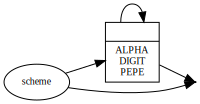

In [ ]:
Let("scheme",-(+(T("ALPHA") | T("DIGIT")| T("PEPE"))))

TODO:
- Añadir el atributo optional a Null con False por defecto
- Al hacer la operación - sobre un grafo , se pone optional a True.
- Al operar con "and"  un  grafo opcional, como segundo operando, se añade al out del resultado los outs del primer operando .
- De esta forma no es necesaria la Clase Neg y las operaciones unarias + y - operan sobre el cuerpo de la regla (RuleBody) y sus subclases.
- De esta forma, los operadores - y + operan sobre Terminales y no Terminales sin cambiar su tipo.

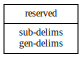

In [ ]:
Let("reserved",T("sub-delims")|T("gen-delims")) 

*Literal* values are provided:

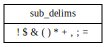

In [ ]:
Let("sub_delims",T("ñllkhñlhñlh",literals="! $ & ( ) * + , ; =")) 

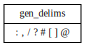

In [ ]:
Let("gen_delims",T("gen_delims",literals=": , / ? # [ ] @"))  

sub-delim terminals and gen-delim terminals are merged in reserved, now with literal content:

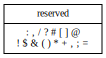

In [ ]:
Let("reserved",n("'gen_delims") | "'sub_delims")  

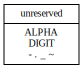

In [ ]:
Let("unreserved",T("",literals="ALPHA \\n DIGIT \\n - . _  ~"))

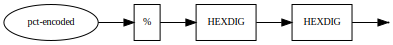

In [ ]:
Let("pct-encoded",T("%") & "'HEXDIG" & "'HEXDIG")

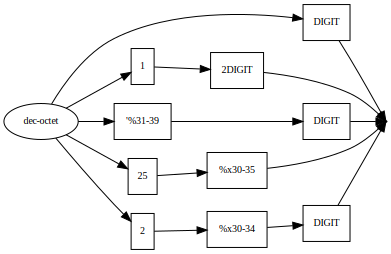

In [ ]:
#dec-octet      = DIGIT                 ; 0-9
#                  / %x31-39 DIGIT         ; 10-99
#                  / "1" 2DIGIT            ; 100-199
#                  / "2" %x30-34 DIGIT     ; 200-249
#                  / "25" %x30-35          ; 250-255
Let("dec-octet",T("DIGIT") | T("'%31-39") & "'DIGIT" | T("1") & "'2DIGIT" | T("2") & "'%x30-34" & "'DIGIT" | T("25") & "'%x30-35")

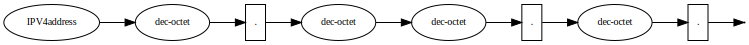

In [ ]:
# IPv4address    = dec-octet "." dec-octet "." dec-octet "." dec-octet
Let("IPV4address",Nt("dec-octet") & "'." & Nt("dec-octet") & Nt("dec-octet") & "'." & Nt("dec-octet") & "'.") 

In [ ]:
print(n("'IPV4address").nCount)

9


#| Hide
TODO: evitar expansión de referencias  por número

```python   

   ifragment      = *( ipchar / "/" / "?" )

  

   ucschar        = %xA0-D7FF / %xF900-FDCF / %xFDF0-FFEF
                  / %x10000-1FFFD / %x20000-2FFFD / %x30000-3FFFD
                  / %x40000-4FFFD / %x50000-5FFFD / %x60000-6FFFD
                  / %x70000-7FFFD / %x80000-8FFFD / %x90000-9FFFD
                  / %xA0000-AFFFD / %xB0000-BFFFD / %xC0000-CFFFD
                  / %xD0000-DFFFD / %xE1000-EFFFD

   
   IP-literal     = "[" ( IPv6address / IPvFuture  ) "]"

   IPvFuture      = "v" 1*HEXDIG "." 1*( unreserved / sub-delims / ":" )

   IPv6address    =                            6( h16 ":" ) ls32
                  /                       "::" 5( h16 ":" ) ls32
                  / [               h16 ] "::" 4( h16 ":" ) ls32
                  / [ *1( h16 ":" ) h16 ] "::" 3( h16 ":" ) ls32
                  / [ *2( h16 ":" ) h16 ] "::" 2( h16 ":" ) ls32
                  / [ *3( h16 ":" ) h16 ] "::"    h16 ":"   ls32
                  / [ *4( h16 ":" ) h16 ] "::"              ls32
                  / [ *5( h16 ":" ) h16 ] "::"              h16
                  / [ *6( h16 ":" ) h16 ] "::"

   h16            = 1*4HEXDIG
   ls32           = ( h16 ":" h16 ) / IPv4address

   

  

   

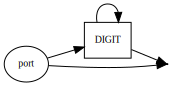

In [ ]:
Let("port",-(+T("DIGIT")))

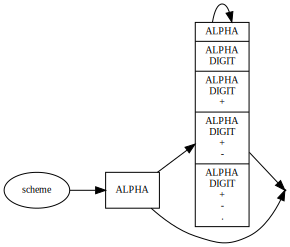

In [ ]:
Let("scheme",T("ALPHA") & -(+(T("ALPHA") | T("DIGIT") | T("+") | T("-") | T(".") )))

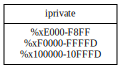

In [ ]:
Let("iprivate",T("%xE000-F8FF") | "'%xF0000-FFFFD" | "'%x100000-10FFFD")

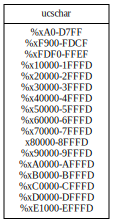

In [ ]:
Let("ucschar",T("%xA0-D7FF") | "'%xF900-FDCF" | "'%xFDF0-FFEF" \
                  | "'%x10000-1FFFD" | "'%x20000-2FFFD" | "'%x30000-3FFFD"\
                  | "'%x40000-4FFFD" | "'%x50000-5FFFD" | "'%x60000-6FFFD"\
                  | "'%x70000-7FFFD" | "'x80000-8FFFD"  | "'%x90000-9FFFD"\
                  | "'%xA0000-AFFFD" | "'%xB0000-BFFFD" | "'%xC0000-CFFFD"\
                  | "'%xD0000-DFFFD" | "'%xE1000-EFFFD")


In [ ]:
 Let("iunreserved",n("_"))

AttributeError: 'Source' object has no attribute 'out'

In [ ]:
 Let("iunreserved",T("ALPHA") | "'DIGIT" | "'-" | "'." | "'_" | "'~" | "'ucschar")

In [ ]:
#| hide 
#TODO: replace - by _ in names and separe literal string with spaces

In [ ]:
#| hide
#  ipchar = iunreserved / pct-encoded / sub-delims / ":"/ "@"
Let("ipchar",n("iunreserved") | "pct_encoded" | "sub_delims" | "':" | "'@") 

In [ ]:
#| hide
# iquery = *( ipchar / iprivate / "/" / "?" )
Let("iquery",-(+(n("'ipchar") | "'iprivate" | "'/" | "'?")))

In [ ]:
#| hide
#   isegment-nz-nc = 1*( iunreserved / pct-encoded / sub-delims / "@" )
#                 ; non-zero-length segment without any colon ":"
Production("isegment_nz_nc",T("isegment_nz_nc",comment="non-zero length \\n segment without \\n any colon ':'"))

In [ ]:
#| hide
# isegment-nz    = 1*ipchar
Production("isegment_nz",n("1*ipchar",comment="Non zero\\nlength segment."))

In [ ]:
#| hide
#   isegment       = *ipchar
Production("isegment",-(+n("'ipchar")))

In [ ]:
#| hide
# ipath-empty    = 0<ipchar>
Production("ipath_empty",n("0*ipchar",comment="Empty \\n path"))

In [ ]:
#| hide
# ipath-rootless = isegment-nz *( "/" isegment )
Production("ipath_rootless",n("isegment_nz") & -(+(n("'/") & "isegment")))

In [ ]:
#| hide
#   ipath-noscheme = isegment-nz-nc *( "/" isegment )
Production("ipath_noscheme",n("isegment_nz_nc") & -(+(n("'/") &"isegment")),expand=True)

In [ ]:
##   ipath-absolute = "/" [ isegment-nz *( "/" isegment ) ]
Production("ipath_absolute",n("'/") & -(n("isegment_nz") & -(+(n("'/") & "isegment"))))

In [ ]:
#| hide
#   ipath-abempty  = *( "/" isegment )
Production("ipath_abempty",-(+(n("/") & "isegment")))

In [ ]:
#| hide
# RFC 3987         Internationalized Resource Identifiers     January 2005
#  IRI -> scheme -> ":" -> ihier-part -> [ "?" iquery ] [ "#" ifragment ]    
Production('IRI',n("scheme") & "':" & "ihier_part" & (-(n("'?") & "iquery")) & (-(n("'#") & "ifragment")),expand=False)

In [ ]:
#| hide
# ihier-part     = "//" iauthority ipath-abempty / ipath-absolute  / ipath-rootless  / ipath-empty
Production("ihier_part",n("'//") & "iauthority" & "ipath_abempty" | "ipath_absolute" | "ipath_rootless" | "ipath_empty",expand=False)

In [ ]:
#| hide
#  IRI-reference  = IRI / irelative-ref
Production("IRI_reference",n("IRI") | "irelative_ref",expand=False)

In [ ]:
#| hide
# irelative-ref  = irelative-part [ "?" iquery ] [ "#" ifragment ]
Production("irelative_ref",n("irelative_part") & -(n("'?") & "iquery") & -(n("'#") & "ifragment"))

In [ ]:
#| hide
#  irelative-part = "//" iauthority ipath-abempty / ipath-absolute
Production("irelative_part",n("'//") & "iauthority" & "ipath_abempty" | "ipath_absolute" | "ipath-noscheme" | "ipath-empty",expand=False)

In [ ]:
#| hide
# absolute-IRI   = scheme ":" ihier-part [ "?" iquery ]
Production("absolute_IRI",n("scheme") & "':" & "ihier_part" & -(n("'?") & "iquery"))

In [ ]:
#| hide
#   iauthority     = [ iuserinfo "@" ] ihost [ ":" port ]
Production("iauthority",-(n("iuserinfo") & "'@") & "ihost" & -(n("':") & "port"))

In [ ]:
#| hide
# iuserinfo      = *( iunreserved / pct-encoded / sub-delims / ":" )
Production("iuserinfo",-(+(n("'iuserinfo",comment="iunreserved | pct-encoded | sub-delims | :"))))

#| hide
   ihost          = IP-literal / IPv4address / ireg-name

   ireg-name      = *( iunreserved / pct-encoded / sub-delims )

   ipath          = ipath-abempty   ; begins with "/" or is empty
                  / ipath-absolute  ; begins with "/" but not "//"
                  / ipath-noscheme  ; begins with a non-colon segment
                  / ipath-rootless  ; begins with a segment
                  / ipath-empty     ; zero characters

In [ ]:
#| hide
#   ipath-abempty  = *( "/" isegment )
Production("ipath_abempty",-(+(n("/") & "isegment")))

In [ ]:
##   ipath-absolute = "/" [ isegment-nz *( "/" isegment ) ]
Production("ipath_absolute",n("'/") & -(n("isegment_nz") & -(+(n("'/") & "isegment"))))

In [ ]:
#| hide
#   ipath-noscheme = isegment-nz-nc *( "/" isegment )
Production("ipath_noscheme",n("isegment_nz_nc") & -(+(n("'/") &"isegment")),expand=True)

In [ ]:
#| hide
# ipath-rootless = isegment-nz *( "/" isegment )
Production("ipath_rootless",n("isegment_nz") & -(+(n("'/") & "isegment")))

In [ ]:
#| hide
# ipath-empty    = 0<ipchar>
Production("ipath_empty",n("0*ipchar",comment="Empty \\n path"))

In [ ]:
#| hide
#   isegment       = *ipchar
Production("isegment",-(+n("'ipchar")))

In [ ]:
#| hide
# isegment-nz    = 1*ipchar
Production("isegment_nz",n("1*ipchar",comment="Non zero\\nlength segment."))

In [ ]:
#| hide
#   isegment-nz-nc = 1*( iunreserved / pct-encoded / sub-delims / "@" )
#                 ; non-zero-length segment without any colon ":"
Production("isegment_nz_nc",T("isegment_nz_nc",comment="non-zero length \\n segment without \\n any colon ':'"))

In [ ]:
#| hide
#  ipchar = iunreserved / pct-encoded / sub-delims / ":"/ "@"
Production("ipchar",n("iunreserved") | "pct_encoded" | "sub_delims" | "':" | "'@") 

In [ ]:
#| hide
# iquery = *( ipchar / iprivate / "/" / "?" )
Production("iquery",n("'ipchar") | "'iprivate" | "'/" | "'?")

```python   

   ifragment      = *( ipchar / "/" / "?" )

   iunreserved    = ALPHA / DIGIT / "-" / "." / "_" / "~" / ucschar

   ucschar        = %xA0-D7FF / %xF900-FDCF / %xFDF0-FFEF
                  / %x10000-1FFFD / %x20000-2FFFD / %x30000-3FFFD
                  / %x40000-4FFFD / %x50000-5FFFD / %x60000-6FFFD
                  / %x70000-7FFFD / %x80000-8FFFD / %x90000-9FFFD
                  / %xA0000-AFFFD / %xB0000-BFFFD / %xC0000-CFFFD
                  / %xD0000-DFFFD / %xE1000-EFFFD

   iprivate       = %xE000-F8FF / %xF0000-FFFFD / %x100000-10FFFD




   The following rules are the same as those in [RFC3986]:

   scheme         = ALPHA *( ALPHA / DIGIT / "+" / "-" / "." )

   port           = *DIGIT

   IP-literal     = "[" ( IPv6address / IPvFuture  ) "]"

   IPvFuture      = "v" 1*HEXDIG "." 1*( unreserved / sub-delims / ":" )

   IPv6address    =                            6( h16 ":" ) ls32
                  /                       "::" 5( h16 ":" ) ls32
                  / [               h16 ] "::" 4( h16 ":" ) ls32
                  / [ *1( h16 ":" ) h16 ] "::" 3( h16 ":" ) ls32
                  / [ *2( h16 ":" ) h16 ] "::" 2( h16 ":" ) ls32
                  / [ *3( h16 ":" ) h16 ] "::"    h16 ":"   ls32
                  / [ *4( h16 ":" ) h16 ] "::"              ls32
                  / [ *5( h16 ":" ) h16 ] "::"              h16
                  / [ *6( h16 ":" ) h16 ] "::"

   h16            = 1*4HEXDIG
   ls32           = ( h16 ":" h16 ) / IPv4address

   IPv4address    = dec-octet "." dec-octet "." dec-octet "." dec-octet

   dec-octet      = DIGIT                 ; 0-9
                  / %x31-39 DIGIT         ; 10-99
                  / "1" 2DIGIT            ; 100-199
                  / "2" %x30-34 DIGIT     ; 200-249
                  / "25" %x30-35          ; 250-255

   pct-encoded    = "%" HEXDIG HEXDIG

   

In [ ]:
#| hide
#   unreserved     = ALPHA / DIGIT / "-" / "." / "_" / "~"
Production("unreserved",T("unreserved") | "'ALPHA" | "'DIGIT" | T("",literals="ALPHA DIGIT \\n - . _  ~"))

In [ ]:
#| hide
#  reserved       = gen-delims / sub-delims
Production("reserved",n("'reserved") | "'gen_delims" | "'sub_delims")  

In [ ]:
#| hide
#   gen-delims     = ":" / "/" / "?" / "#" / "[" / "]" / "@"
Production("gen_delims",n("'gen_delims",literals=": , / ? # [ ] @"))  

In [ ]:
#| hide
#  sub-delims   = "!" / "$" / "&" / "'" / "(" / ")" / "*" / "+" / "," / ";" / "="
#Production("sub_delims",T("sub_delims",literals=["!","$","&","'","(",")","*","+",",",";","="]))
Production("sub_delims",n("'sub_delims",literals="! $ & ( ) * + , ; =")) # FALTA LA COMILLA

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()